In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

pd.set_option("display.max_columns", None)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
archivos = files.upload()

Saving dataset_afluencia_real_preparado.csv to dataset_afluencia_real_preparado.csv


In [3]:
nombre_archivo = next(iter(archivos))

df = pd.read_csv(
    nombre_archivo,
    encoding="utf-8-sig"
)

df["Fecha"] = pd.to_datetime(
    df["Fecha"],
    errors="coerce"
)

df = (
    df.sort_values(["Fecha", "Hora"])
    .reset_index(drop=True)
)

print("Archivo:", nombre_archivo)
print("Dimensiones originales:", df.shape)
print("Periodo:", df["Fecha"].min(), "-", df["Fecha"].max())
print("Valores nulos:", df.isnull().sum().sum())

df.head(10)

Archivo: dataset_afluencia_real_preparado.csv
Dimensiones originales: (1248, 11)
Periodo: 2026-04-10 00:00:00 - 2026-09-28 00:00:00
Valores nulos: 0


,Fecha,Hora,Sede,CantidadIngresos,DiaSemana,Mes,DiaMes,SemanaAnio,EsLunes,EsViernes,Turno
0,2026-04-10,8,Central,0,4,4,10,15,0,1,Mañana
1,2026-04-10,9,Central,0,4,4,10,15,0,1,Mañana
2,2026-04-10,10,Central,0,4,4,10,15,0,1,Mañana
3,2026-04-10,11,Central,0,4,4,10,15,0,1,Mañana
4,2026-04-10,12,Central,2,4,4,10,15,0,1,Mañana
5,2026-04-10,13,Central,2,4,4,10,15,0,1,Tarde
6,2026-04-10,14,Central,0,4,4,10,15,0,1,Tarde
7,2026-04-10,15,Central,0,4,4,10,15,0,1,Tarde
8,2026-04-10,16,Central,0,4,4,10,15,0,1,Tarde
9,2026-04-10,17,Central,0,4,4,10,15,0,1,Tarde


In [4]:
# Ordenamos por hora y fecha para trabajar
# cronológicamente dentro de cada hora.
df_mejorado = (
    df.sort_values(["Hora", "Fecha"])
    .reset_index(drop=True)
    .copy()
)

grupo_hora = df_mejorado.groupby(
    "Hora"
)["CantidadIngresos"]

# Ingresos registrados en esa misma hora
# durante el día activo anterior.
df_mejorado["IngresosDiaAnterior"] = (
    grupo_hora.shift(1)
)

# Ingresos registrados en esa misma hora
# cinco días activos antes.
df_mejorado["IngresosCincoDiasAntes"] = (
    grupo_hora.shift(5)
)

# Promedio de esa hora durante los cinco días
# anteriores. shift(1) evita usar el valor actual.
df_mejorado["PromedioMovil5"] = (
    grupo_hora.transform(
        lambda serie:
        serie.shift(1)
        .rolling(
            window=5,
            min_periods=3
        )
        .mean()
    )
)

# Promedio histórico de esa hora, calculado
# únicamente con observaciones anteriores.
df_mejorado["PromedioHistoricoHora"] = (
    grupo_hora.transform(
        lambda serie:
        serie.shift(1)
        .expanding(
            min_periods=3
        )
        .mean()
    )
)

# Diferencia entre el día anterior y el
# promedio reciente.
df_mejorado["TendenciaReciente"] = (
    df_mejorado["IngresosDiaAnterior"]
    - df_mejorado["PromedioMovil5"]
)

df_mejorado.head(20)

,Fecha,Hora,Sede,CantidadIngresos,DiaSemana,Mes,DiaMes,SemanaAnio,EsLunes,EsViernes,Turno,IngresosDiaAnterior,IngresosCincoDiasAntes,PromedioMovil5,PromedioHistoricoHora,TendenciaReciente
0,2026-04-10,8,Central,0,4,4,10,15,0,1,Mañana,NaN,NaN,NaN,NaN,NaN
1,2026-04-29,8,Central,0,2,4,29,18,0,0,Mañana,0.0,NaN,NaN,NaN,NaN
2,2026-05-04,8,Central,0,0,5,4,19,1,0,Mañana,0.0,NaN,NaN,NaN,NaN
3,2026-05-05,8,Central,0,1,5,5,19,0,0,Mañana,0.0,NaN,0.0,0.000000,0.0
4,2026-05-12,8,Central,15,1,5,12,20,0,0,Mañana,0.0,NaN,0.0,0.000000,0.0
5,2026-05-13,8,Central,72,2,5,13,20,0,0,Mañana,15.0,0.0,3.0,3.000000,12.0
6,2026-05-14,8,Central,44,3,5,14,20,0,0,Mañana,72.0,0.0,17.4,14.500000,54.6
7,2026-05-15,8,Central,30,4,5,15,20,0,1,Mañana,44.0,0.0,26.2,18.714286,17.8
8,2026-05-18,8,Central,22,0,5,18,21,1,0,Mañana,30.0,0.0,32.2,20.125000,-2.2
9,2026-05-19,8,Central,36,1,5,19,21,0,0,Mañana,22.0,15.0,36.6,20.333333,-14.6


In [5]:
verificacion_hora = df_mejorado[
    df_mejorado["Hora"] == 10
][[
    "Fecha",
    "Hora",
    "CantidadIngresos",
    "IngresosDiaAnterior",
    "IngresosCincoDiasAntes",
    "PromedioMovil5",
    "PromedioHistoricoHora",
    "TendenciaReciente"
]].head(12)

verificacion_hora

,Fecha,Hora,CantidadIngresos,IngresosDiaAnterior,IngresosCincoDiasAntes,PromedioMovil5,PromedioHistoricoHora,TendenciaReciente
192,2026-04-10,10,0,NaN,NaN,NaN,NaN,NaN
193,2026-04-29,10,0,0.0,NaN,NaN,NaN,NaN
194,2026-05-04,10,0,0.0,NaN,NaN,NaN,NaN
195,2026-05-05,10,0,0.0,NaN,0.0,0.000000,0.0
196,2026-05-12,10,34,0.0,NaN,0.0,0.000000,0.0
197,2026-05-13,10,28,34.0,0.0,6.8,6.800000,27.2
198,2026-05-14,10,43,28.0,0.0,12.4,10.333333,15.6
199,2026-05-15,10,21,43.0,0.0,21.0,15.000000,22.0
200,2026-05-18,10,33,21.0,0.0,25.2,15.750000,-4.2
201,2026-05-19,10,26,33.0,34.0,31.8,17.666667,1.2


In [6]:
columnas_historicas = [
    "IngresosDiaAnterior",
    "IngresosCincoDiasAntes",
    "PromedioMovil5",
    "PromedioHistoricoHora",
    "TendenciaReciente"
]

print("Nulos antes de limpiar:")
print(
    df_mejorado[columnas_historicas]
    .isnull()
    .sum()
)

df_mejorado = (
    df_mejorado
    .dropna(subset=columnas_historicas)
    .sort_values(["Fecha", "Hora"])
    .reset_index(drop=True)
)

print("\nDimensiones después de limpiar:",
      df_mejorado.shape)

print("Periodo utilizable:",
      df_mejorado["Fecha"].min(),
      "-",
      df_mejorado["Fecha"].max())

print("Valores nulos restantes:",
      df_mejorado.isnull().sum().sum())

Nulos antes de limpiar:
IngresosDiaAnterior       13
IngresosCincoDiasAntes    65
PromedioMovil5            39
PromedioHistoricoHora     39
TendenciaReciente         39
dtype: int64

Dimensiones después de limpiar: (1183, 16)
Periodo utilizable: 2026-05-13 00:00:00 - 2026-09-28 00:00:00
Valores nulos restantes: 0


In [7]:
fechas_unicas = np.array(
    sorted(
        df_mejorado["Fecha"]
        .dt.normalize()
        .unique()
    )
)

punto_corte = int(
    len(fechas_unicas) * 0.80
)

fechas_train = fechas_unicas[:punto_corte]
fechas_test = fechas_unicas[punto_corte:]

df_train = df_mejorado[
    df_mejorado["Fecha"]
    .dt.normalize()
    .isin(fechas_train)
].copy()

df_test = df_mejorado[
    df_mejorado["Fecha"]
    .dt.normalize()
    .isin(fechas_test)
].copy()

print("Fechas utilizables:", len(fechas_unicas))
print("Fechas de entrenamiento:", len(fechas_train))
print("Fechas de prueba:", len(fechas_test))

print("\nEntrenamiento:")
print(df_train["Fecha"].min(),
      "-",
      df_train["Fecha"].max())
print("Filas:", len(df_train))

print("\nPrueba:")
print(df_test["Fecha"].min(),
      "-",
      df_test["Fecha"].max())
print("Filas:", len(df_test))

assert df_train["Fecha"].max() < df_test["Fecha"].min(), \
    "Existe cruce entre entrenamiento y prueba"

print("\nDivisión temporal correcta")

Fechas utilizables: 91
Fechas de entrenamiento: 72
Fechas de prueba: 19

Entrenamiento:
2026-05-13 00:00:00 - 2026-08-31 00:00:00
Filas: 936

Prueba:
2026-09-01 00:00:00 - 2026-09-28 00:00:00
Filas: 247

División temporal correcta


In [8]:
columnas_revision = [
    "Fecha",
    "Hora",
    "CantidadIngresos",
    "IngresosDiaAnterior",
    "IngresosCincoDiasAntes",
    "PromedioMovil5",
    "PromedioHistoricoHora",
    "TendenciaReciente"
]

df_test[columnas_revision].head(15)

,Fecha,Hora,CantidadIngresos,IngresosDiaAnterior,IngresosCincoDiasAntes,PromedioMovil5,PromedioHistoricoHora,TendenciaReciente
936,2026-09-01,8,31,35.0,34.0,30.8,35.688312,4.2
937,2026-09-01,9,25,28.0,22.0,28.2,31.883117,-0.2
938,2026-09-01,10,72,21.0,35.0,24.8,32.662338,-3.8
939,2026-09-01,11,36,17.0,17.0,16.6,29.987013,0.4
940,2026-09-01,12,16,21.0,16.0,15.0,20.831169,6.0
941,2026-09-01,13,74,44.0,28.0,23.4,32.103896,20.6
942,2026-09-01,14,39,41.0,15.0,25.8,39.090909,15.2
943,2026-09-01,15,46,32.0,31.0,34.8,37.909091,-2.8
944,2026-09-01,16,35,79.0,22.0,35.8,33.688312,43.2
945,2026-09-01,17,24,26.0,25.0,20.2,25.519481,5.8


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    classification_report,
    confusion_matrix
)

print("Modelos y métricas importados correctamente")

Modelos y métricas importados correctamente


In [10]:
limite_bajo = int(
    df_train["CantidadIngresos"].quantile(0.33)
)

limite_alto = int(
    df_train["CantidadIngresos"].quantile(0.66)
)

print("Límite Bajo:", limite_bajo)
print("Límite Alto:", limite_alto)

def asignar_nivel(cantidad):
    if cantidad <= limite_bajo:
        return "Bajo"
    elif cantidad <= limite_alto:
        return "Medio"
    else:
        return "Alto"

df_train["NivelAfluencia"] = (
    df_train["CantidadIngresos"]
    .apply(asignar_nivel)
)

df_test["NivelAfluencia"] = (
    df_test["CantidadIngresos"]
    .apply(asignar_nivel)
)

print("\nDistribución de entrenamiento:")
print(
    df_train["NivelAfluencia"]
    .value_counts()
)

print("\nDistribución de prueba:")
print(
    df_test["NivelAfluencia"]
    .value_counts()
)

Límite Bajo: 7
Límite Alto: 35

Distribución de entrenamiento:
NivelAfluencia
Bajo     319
Alto     318
Medio    299
Name: count, dtype: int64

Distribución de prueba:
NivelAfluencia
Medio    117
Alto      75
Bajo      55
Name: count, dtype: int64


In [11]:
variables = [
    "Hora",
    "DiaSemana",
    "Mes",
    "DiaMes",
    "SemanaAnio",
    "EsLunes",
    "EsViernes",
    "IngresosDiaAnterior",
    "IngresosCincoDiasAntes",
    "PromedioMovil5",
    "PromedioHistoricoHora",
    "TendenciaReciente"
]

X_train = df_train[variables].copy()
X_test = df_test[variables].copy()

y_train = df_train["NivelAfluencia"].copy()
y_test = df_test["NivelAfluencia"].copy()

print("Variables predictoras:", len(variables))
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

assert "CantidadIngresos" not in variables, \
    "CantidadIngresos no debe utilizarse como entrada"

print("\nNo existe fuga directa de la variable objetivo")

Variables predictoras: 12
X_train: (936, 12)
X_test: (247, 12)
y_train: (936,)
y_test: (247,)

No existe fuga directa de la variable objetivo


In [12]:
modelos = {
    "Regresión logística": Pipeline([
        ("escalador", StandardScaler()),
        ("modelo", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Árbol de decisión": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.04,
        max_depth=2,
        min_samples_leaf=8,
        random_state=42
    )
}

print("Modelos preparados:")
for nombre in modelos:
    print("-", nombre)

Modelos preparados:
- Regresión logística
- Árbol de decisión
- Random Forest
- Gradient Boosting


In [13]:
pesos_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Cantidad de pesos:", len(pesos_train))

resumen_pesos = pd.DataFrame({
    "Nivel": y_train,
    "Peso": pesos_train
}).groupby("Nivel").agg(
    Cantidad=("Nivel", "size"),
    PesoPromedio=("Peso", "mean")
)

resumen_pesos

Cantidad de pesos: 936


,Cantidad,PesoPromedio
Nivel,,
Alto,318,0.981132
Bajo,319,0.978056
Medio,299,1.043478


In [14]:
resultados = []
predicciones = {}
modelos_entrenados = {}

for nombre, modelo in modelos.items():

    if nombre == "Gradient Boosting":
        modelo.fit(
            X_train,
            y_train,
            sample_weight=pesos_train
        )
    else:
        modelo.fit(
            X_train,
            y_train
        )

    pred = modelo.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        pred
    )

    f1_macro = f1_score(
        y_test,
        pred,
        average="macro",
        zero_division=0
    )

    recall_alto = recall_score(
        y_test,
        pred,
        labels=["Alto"],
        average=None,
        zero_division=0
    )[0]

    precision_alto = precision_score(
        y_test,
        pred,
        labels=["Alto"],
        average=None,
        zero_division=0
    )[0]

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy,
        "F1_macro": f1_macro,
        "Recall_Alto": recall_alto,
        "Precision_Alto": precision_alto
    })

    predicciones[nombre] = pred
    modelos_entrenados[nombre] = modelo

print("Entrenamiento finalizado")

Entrenamiento finalizado


In [15]:
resultados_df = pd.DataFrame(
    resultados
)

resultados_df = (
    resultados_df
    .sort_values(
        by=["F1_macro", "Recall_Alto"],
        ascending=False
    )
    .reset_index(drop=True)
)

resultados_mostrar = resultados_df.copy()

columnas_metricas = [
    "Accuracy",
    "F1_macro",
    "Recall_Alto",
    "Precision_Alto"
]

for columna in columnas_metricas:
    resultados_mostrar[columna] = (
        resultados_mostrar[columna] * 100
    ).round(2)

resultados_mostrar

,Modelo,Accuracy,F1_macro,Recall_Alto,Precision_Alto
0,Random Forest,55.47,51.66,28.00,52.50
1,Gradient Boosting,57.09,50.21,16.00,66.67
2,Regresión logística,44.94,43.29,22.67,62.96
3,Árbol de decisión,40.49,34.75,5.33,20.00


In [16]:
resultados_anteriores = pd.DataFrame({
    "Modelo": [
        "Regresión logística",
        "Gradient Boosting",
        "Árbol de decisión",
        "Random Forest"
    ],
    "F1_anterior": [
        16.24,
        38.86,
        31.26,
        27.26
    ],
    "Recall_Alto_anterior": [
        11.25,
        0.00,
        0.00,
        0.00
    ]
})

comparacion = resultados_mostrar.merge(
    resultados_anteriores,
    on="Modelo",
    how="left"
)

comparacion["Mejora_F1"] = (
    comparacion["F1_macro"]
    - comparacion["F1_anterior"]
).round(2)

comparacion["Mejora_Recall_Alto"] = (
    comparacion["Recall_Alto"]
    - comparacion["Recall_Alto_anterior"]
).round(2)

comparacion

,Modelo,Accuracy,F1_macro,Recall_Alto,Precision_Alto,F1_anterior,Recall_Alto_anterior,Mejora_F1,Mejora_Recall_Alto
0,Random Forest,55.47,51.66,28.00,52.50,27.26,0.00,24.40,28.00
1,Gradient Boosting,57.09,50.21,16.00,66.67,38.86,0.00,11.35,16.00
2,Regresión logística,44.94,43.29,22.67,62.96,16.24,11.25,27.05,11.42
3,Árbol de decisión,40.49,34.75,5.33,20.00,31.26,0.00,3.49,5.33


In [17]:
mejor_nombre = resultados_df.iloc[0]["Modelo"]
mejor_modelo = modelos_entrenados[mejor_nombre]
mejor_pred = predicciones[mejor_nombre]

print("Mejor modelo provisional:", mejor_nombre)

print("\nMétricas:")
print(
    resultados_mostrar[
        resultados_mostrar["Modelo"] == mejor_nombre
    ]
)

Mejor modelo provisional: Random Forest

Métricas:
          Modelo  Accuracy  F1_macro  Recall_Alto  Precision_Alto
0  Random Forest     55.47     51.66         28.0            52.5


In [18]:
orden_clases = [
    "Bajo",
    "Medio",
    "Alto"
]

print(
    classification_report(
        y_test,
        mejor_pred,
        labels=orden_clases,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Bajo       0.47      0.62      0.53        55
       Medio       0.61      0.70      0.65       117
        Alto       0.53      0.28      0.37        75

    accuracy                           0.55       247
   macro avg       0.53      0.53      0.52       247
weighted avg       0.55      0.55      0.54       247



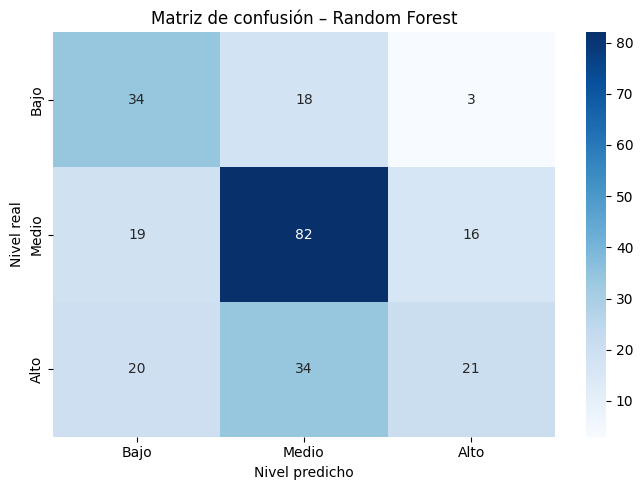

In [19]:
matriz = confusion_matrix(
    y_test,
    mejor_pred,
    labels=orden_clases
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=orden_clases,
    yticklabels=orden_clases
)

plt.title(
    f"Matriz de confusión – {mejor_nombre}"
)
plt.xlabel("Nivel predicho")
plt.ylabel("Nivel real")
plt.tight_layout()
plt.show()

In [20]:
resultado_prueba = df_test[[
    "Fecha",
    "Hora",
    "CantidadIngresos",
    "NivelAfluencia"
]].copy()

resultado_prueba["NivelPredicho"] = mejor_pred

casos_altos = resultado_prueba[
    resultado_prueba["NivelAfluencia"] == "Alto"
]

altos_detectados = (
    casos_altos["NivelPredicho"] == "Alto"
).sum()

total_altos = len(casos_altos)

print("Casos reales de afluencia alta:", total_altos)
print("Casos altos detectados:", altos_detectados)
print(
    "Porcentaje detectado:",
    round(
        altos_detectados / total_altos * 100,
        2
    ),
    "%"
)

casos_altos.head(20)

Casos reales de afluencia alta: 75
Casos altos detectados: 21
Porcentaje detectado: 28.0 %


,Fecha,Hora,CantidadIngresos,NivelAfluencia,NivelPredicho
938,2026-09-01,10,72,Alto,Bajo
939,2026-09-01,11,36,Alto,Medio
941,2026-09-01,13,74,Alto,Medio
942,2026-09-01,14,39,Alto,Medio
943,2026-09-01,15,46,Alto,Bajo
954,2026-09-02,13,64,Alto,Medio
955,2026-09-02,14,40,Alto,Medio
957,2026-09-02,16,56,Alto,Medio
962,2026-09-03,8,52,Alto,Bajo
963,2026-09-03,9,40,Alto,Bajo


### Ajuste temporal y priorización de la afluencia alta

In [22]:
# Obtener las fechas del conjunto de entrenamiento original
fechas_train = sorted(df_train["Fecha"].unique())

# 80 % para entrenamiento interno y 20 % para validación
posicion_corte = int(len(fechas_train) * 0.80)

fechas_entrenamiento_interno = fechas_train[:posicion_corte]
fechas_validacion = fechas_train[posicion_corte:]

df_entrenamiento_interno = df_train[
    df_train["Fecha"].isin(fechas_entrenamiento_interno)
].copy()

df_validacion = df_train[
    df_train["Fecha"].isin(fechas_validacion)
].copy()

X_entrenamiento_interno = df_entrenamiento_interno[variables].copy()
y_entrenamiento_interno = df_entrenamiento_interno["NivelAfluencia"].copy()

X_validacion = df_validacion[variables].copy()
y_validacion = df_validacion["NivelAfluencia"].copy()

print("Entrenamiento interno:")
print("Filas:", len(df_entrenamiento_interno))
print(
    "Periodo:",
    df_entrenamiento_interno["Fecha"].min(),
    "a",
    df_entrenamiento_interno["Fecha"].max()
)

print("\nValidación:")
print("Filas:", len(df_validacion))
print(
    "Periodo:",
    df_validacion["Fecha"].min(),
    "a",
    df_validacion["Fecha"].max()
)

print("\n¿Existe superposición de fechas?:",
      bool(
          set(df_entrenamiento_interno["Fecha"])
          & set(df_validacion["Fecha"])
      ))

Entrenamiento interno:
Filas: 741
Periodo: 2026-05-13 00:00:00 a 2026-08-10 00:00:00

Validación:
Filas: 195
Periodo: 2026-08-11 00:00:00 a 2026-08-31 00:00:00

¿Existe superposición de fechas?: False


## Ajuste de Random Forest para detectar afluencia alta

In [23]:
from itertools import product

# Diferentes configuraciones que probaremos
pesos_alto = [1.0, 1.5, 2.0, 3.0, 4.0]
profundidades = [6, 8, 10, None]
minimos_hoja = [2, 4, 6]

resultados_ajuste = []
modelos_ajustados = {}

for peso_alto, profundidad, minimo_hoja in product(
    pesos_alto,
    profundidades,
    minimos_hoja
):
    nombre_configuracion = (
        f"alto_{peso_alto}_prof_{profundidad}_hoja_{minimo_hoja}"
    )

    modelo = RandomForestClassifier(
        n_estimators=400,
        max_depth=profundidad,
        min_samples_leaf=minimo_hoja,
        class_weight={
            "Bajo": 1.0,
            "Medio": 1.0,
            "Alto": peso_alto
        },
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(
        X_entrenamiento_interno,
        y_entrenamiento_interno
    )

    pred_validacion = modelo.predict(X_validacion)

    accuracy = accuracy_score(
        y_validacion,
        pred_validacion
    )

    f1_macro = f1_score(
        y_validacion,
        pred_validacion,
        average="macro",
        zero_division=0
    )

    recall_alto = recall_score(
        y_validacion,
        pred_validacion,
        labels=["Alto"],
        average=None,
        zero_division=0
    )[0]

    precision_alto = precision_score(
        y_validacion,
        pred_validacion,
        labels=["Alto"],
        average=None,
        zero_division=0
    )[0]

    # Puntaje combinado: equilibrio general y detección de nivel alto
    puntaje = (0.50 * f1_macro) + (0.50 * recall_alto)

    resultados_ajuste.append({
        "Configuracion": nombre_configuracion,
        "Peso_Alto": peso_alto,
        "Profundidad": str(profundidad),
        "Minimo_Hoja": minimo_hoja,
        "Accuracy": accuracy,
        "F1_Macro": f1_macro,
        "Recall_Alto": recall_alto,
        "Precision_Alto": precision_alto,
        "Puntaje": puntaje
    })

    modelos_ajustados[nombre_configuracion] = modelo

resultados_ajuste_df = pd.DataFrame(resultados_ajuste)

# Evitamos elegir un modelo que detecte "Alto"
# a costa de demasiados errores generales
candidatos = resultados_ajuste_df[
    (resultados_ajuste_df["Accuracy"] >= 0.45) &
    (resultados_ajuste_df["Precision_Alto"] >= 0.35)
].copy()

if candidatos.empty:
    print("Ninguna configuración cumplió las condiciones mínimas.")
    candidatos = resultados_ajuste_df.copy()

mejores_configuraciones = candidatos.sort_values(
    by=["Puntaje", "F1_Macro", "Accuracy"],
    ascending=False
).head(10)

columnas_porcentaje = [
    "Accuracy",
    "F1_Macro",
    "Recall_Alto",
    "Precision_Alto",
    "Puntaje"
]

tabla_resultados = mejores_configuraciones.copy()

for columna in columnas_porcentaje:
    tabla_resultados[columna] = (
        tabla_resultados[columna] * 100
    ).round(2)

tabla_resultados.reset_index(drop=True)

Ninguna configuración cumplió las condiciones mínimas.


,Configuracion,Peso_Alto,Profundidad,Minimo_Hoja,Accuracy,F1_Macro,Recall_Alto,Precision_Alto,Puntaje
0,alto_1.0_prof_6_hoja_2,1.0,6,2,68.21,28.18,0.0,0.0,14.09
1,alto_1.0_prof_6_hoja_4,1.0,6,4,68.21,28.18,0.0,0.0,14.09
2,alto_1.0_prof_6_hoja_6,1.0,6,6,68.21,28.18,0.0,0.0,14.09
3,alto_1.0_prof_8_hoja_2,1.0,8,2,68.21,28.18,0.0,0.0,14.09
4,alto_1.0_prof_8_hoja_4,1.0,8,4,68.21,28.18,0.0,0.0,14.09
5,alto_1.0_prof_8_hoja_6,1.0,8,6,68.21,28.18,0.0,0.0,14.09
6,alto_1.0_prof_10_hoja_2,1.0,10,2,68.21,28.18,0.0,0.0,14.09
7,alto_1.0_prof_10_hoja_4,1.0,10,4,68.21,28.18,0.0,0.0,14.09
8,alto_1.0_prof_10_hoja_6,1.0,10,6,68.21,28.18,0.0,0.0,14.09
9,alto_1.0_prof_None_hoja_2,1.0,None,2,68.21,28.18,0.0,0.0,14.09


## Diagnóstico de las clases en entrenamiento y validación

In [28]:
orden_niveles = ["Bajo", "Medio", "Alto"]

def mostrar_distribucion(nombre, datos):
    cantidades = (
        datos["NivelAfluencia"]
        .value_counts()
        .reindex(orden_niveles, fill_value=0)
    )

    porcentajes = (
        datos["NivelAfluencia"]
        .value_counts(normalize=True)
        .reindex(orden_niveles, fill_value=0)
        .mul(100)
        .round(2)
    )

    resumen = pd.DataFrame({
        "Cantidad": cantidades,
        "Porcentaje": porcentajes
    })

    print(f"\n{nombre}")
    display(resumen)

mostrar_distribucion(
    "Entrenamiento interno",
    df_entrenamiento_interno
)

mostrar_distribucion(
    "Validación",
    df_validacion
)

mostrar_distribucion(
    "Prueba final",
    df_test
)

print("\nDistribución mensual completa:")

# Unir entrenamiento y prueba para reconstruir
# el conjunto completo utilizado por el modelo
df_completo_modelo = pd.concat(
    [df_train, df_test],
    ignore_index=True
).sort_values(["Fecha", "Hora"])

distribucion_mensual = pd.crosstab(
    df_completo_modelo["Mes"],
    df_completo_modelo["NivelAfluencia"]
).reindex(
    columns=orden_niveles,
    fill_value=0
)

display(distribucion_mensual)


Entrenamiento interno


,Cantidad,Porcentaje
NivelAfluencia,,
Bajo,187,25.24
Medio,244,32.93
Alto,310,41.84



Validación


,Cantidad,Porcentaje
NivelAfluencia,,
Bajo,132,67.69
Medio,55,28.21
Alto,8,4.10



Prueba final


,Cantidad,Porcentaje
NivelAfluencia,,
Bajo,55,22.27
Medio,117,47.37
Alto,75,30.36



Distribución mensual completa:


NivelAfluencia,Bajo,Medio,Alto
Mes,,,
5,27,76,66
6,75,99,99
7,26,63,145
8,191,61,8
9,55,117,75


## Validación temporal mediante ventanas expansivas

In [29]:
# Los meses se mantienen en orden cronológico.
# Septiembre no participa porque continúa reservado
# exclusivamente como prueba final.

bloques_temporales = [
    {
        "Nombre": "Mayo → Junio",
        "Meses_Entrenamiento": [5],
        "Mes_Validacion": 6
    },
    {
        "Nombre": "Mayo-Junio → Julio",
        "Meses_Entrenamiento": [5, 6],
        "Mes_Validacion": 7
    },
    {
        "Nombre": "Mayo-Julio → Agosto",
        "Meses_Entrenamiento": [5, 6, 7],
        "Mes_Validacion": 8
    }
]

resumen_bloques = []

for bloque in bloques_temporales:
    datos_entrenamiento = df_train[
        df_train["Mes"].isin(
            bloque["Meses_Entrenamiento"]
        )
    ]

    datos_validacion = df_train[
        df_train["Mes"] == bloque["Mes_Validacion"]
    ]

    resumen_bloques.append({
        "Bloque": bloque["Nombre"],
        "Filas_entrenamiento": len(datos_entrenamiento),
        "Filas_validacion": len(datos_validacion),
        "Alto_entrenamiento": (
            datos_entrenamiento["NivelAfluencia"] == "Alto"
        ).sum(),
        "Alto_validacion": (
            datos_validacion["NivelAfluencia"] == "Alto"
        ).sum(),
        "Fecha_max_entrenamiento":
            datos_entrenamiento["Fecha"].max(),
        "Fecha_min_validacion":
            datos_validacion["Fecha"].min()
    })

resumen_bloques_df = pd.DataFrame(resumen_bloques)

display(resumen_bloques_df)

# Comprobación metodológica:
# toda validación debe ocurrir después de su entrenamiento
assert all(
    resumen_bloques_df["Fecha_max_entrenamiento"]
    <
    resumen_bloques_df["Fecha_min_validacion"]
)

print(
    "Validación temporal correcta:",
    "ningún bloque utiliza datos futuros."
)

,Bloque,Filas_entrenamiento,Filas_validacion,Alto_entrenamiento,Alto_validacion,Fecha_max_entrenamiento,Fecha_min_validacion
0,Mayo → Junio,169,273,66,99,2026-05-29,2026-06-01
1,Mayo-Junio → Julio,442,234,165,145,2026-06-30,2026-07-01
2,Mayo-Julio → Agosto,676,260,310,8,2026-07-31,2026-08-03


Validación temporal correcta: ningún bloque utiliza datos futuros.


## Ajuste de Random Forest con validación temporal expansiva

In [30]:
from itertools import product

# Configuraciones que se evaluarán
pesos_alto_cv = [1.0, 1.5, 2.0, 3.0, 4.0]
profundidades_cv = [6, 10, None]
minimos_hoja_cv = [2, 4]

resultados_cv = []
resultados_por_bloque = []

total_configuraciones = (
    len(pesos_alto_cv)
    * len(profundidades_cv)
    * len(minimos_hoja_cv)
)

print(
    "Configuraciones que serán evaluadas:",
    total_configuraciones
)

for peso_alto, profundidad, minimo_hoja in product(
    pesos_alto_cv,
    profundidades_cv,
    minimos_hoja_cv
):
    nombre_configuracion = (
        f"alto_{peso_alto}_"
        f"prof_{profundidad}_"
        f"hoja_{minimo_hoja}"
    )

    metricas_bloques = []

    for bloque in bloques_temporales:
        datos_entrenamiento = df_train[
            df_train["Mes"].isin(
                bloque["Meses_Entrenamiento"]
            )
        ].copy()

        datos_validacion = df_train[
            df_train["Mes"] == bloque["Mes_Validacion"]
        ].copy()

        X_entrenamiento_bloque = (
            datos_entrenamiento[variables]
        )

        y_entrenamiento_bloque = (
            datos_entrenamiento["NivelAfluencia"]
        )

        X_validacion_bloque = (
            datos_validacion[variables]
        )

        y_validacion_bloque = (
            datos_validacion["NivelAfluencia"]
        )

        modelo_cv = RandomForestClassifier(
            n_estimators=300,
            max_depth=profundidad,
            min_samples_leaf=minimo_hoja,
            class_weight={
                "Bajo": 1.0,
                "Medio": 1.0,
                "Alto": peso_alto
            },
            random_state=42,
            n_jobs=-1
        )

        modelo_cv.fit(
            X_entrenamiento_bloque,
            y_entrenamiento_bloque
        )

        prediccion_bloque = modelo_cv.predict(
            X_validacion_bloque
        )

        accuracy_bloque = accuracy_score(
            y_validacion_bloque,
            prediccion_bloque
        )

        f1_bloque = f1_score(
            y_validacion_bloque,
            prediccion_bloque,
            average="macro",
            zero_division=0
        )

        recall_alto_bloque = recall_score(
            y_validacion_bloque,
            prediccion_bloque,
            labels=["Alto"],
            average=None,
            zero_division=0
        )[0]

        precision_alto_bloque = precision_score(
            y_validacion_bloque,
            prediccion_bloque,
            labels=["Alto"],
            average=None,
            zero_division=0
        )[0]

        metricas_bloques.append({
            "Accuracy": accuracy_bloque,
            "F1_Macro": f1_bloque,
            "Recall_Alto": recall_alto_bloque,
            "Precision_Alto": precision_alto_bloque
        })

        resultados_por_bloque.append({
            "Configuracion": nombre_configuracion,
            "Bloque": bloque["Nombre"],
            "Accuracy": accuracy_bloque,
            "F1_Macro": f1_bloque,
            "Recall_Alto": recall_alto_bloque,
            "Precision_Alto": precision_alto_bloque
        })

    metricas_bloques_df = pd.DataFrame(
        metricas_bloques
    )

    accuracy_promedio = (
        metricas_bloques_df["Accuracy"].mean()
    )

    f1_promedio = (
        metricas_bloques_df["F1_Macro"].mean()
    )

    recall_alto_promedio = (
        metricas_bloques_df["Recall_Alto"].mean()
    )

    precision_alto_promedio = (
        metricas_bloques_df["Precision_Alto"].mean()
    )

    # Se prioriza ligeramente el recall de la clase Alto
    puntaje_cv = (
        0.45 * f1_promedio
        +
        0.55 * recall_alto_promedio
    )

    resultados_cv.append({
        "Configuracion": nombre_configuracion,
        "Peso_Alto": peso_alto,
        "Profundidad": str(profundidad),
        "Minimo_Hoja": minimo_hoja,
        "Accuracy_Promedio": accuracy_promedio,
        "F1_Promedio": f1_promedio,
        "Recall_Alto_Promedio": recall_alto_promedio,
        "Precision_Alto_Promedio":
            precision_alto_promedio,
        "Puntaje_CV": puntaje_cv
    })

print("Validación temporal terminada.")

Configuraciones que serán evaluadas: 30
Validación temporal terminada.


In [31]:
resultados_cv_df = pd.DataFrame(resultados_cv)

candidatos_cv = resultados_cv_df[
    (resultados_cv_df["Accuracy_Promedio"] >= 0.40)
    &
    (resultados_cv_df["Precision_Alto_Promedio"] >= 0.30)
].copy()

if candidatos_cv.empty:
    print(
        "Ninguna configuración cumplió "
        "las condiciones mínimas."
    )
    candidatos_cv = resultados_cv_df.copy()

mejores_cv = candidatos_cv.sort_values(
    by=[
        "Puntaje_CV",
        "F1_Promedio",
        "Accuracy_Promedio"
    ],
    ascending=False
).head(10)

tabla_mejores_cv = mejores_cv.copy()

columnas_metricas_cv = [
    "Accuracy_Promedio",
    "F1_Promedio",
    "Recall_Alto_Promedio",
    "Precision_Alto_Promedio",
    "Puntaje_CV"
]

for columna in columnas_metricas_cv:
    tabla_mejores_cv[columna] = (
        tabla_mejores_cv[columna] * 100
    ).round(2)

tabla_mejores_cv.reset_index(drop=True)

,Configuracion,Peso_Alto,Profundidad,Minimo_Hoja,Accuracy_Promedio,F1_Promedio,Recall_Alto_Promedio,Precision_Alto_Promedio,Puntaje_CV
0,alto_3.0_prof_6_hoja_4,3.0,6,4,53.63,49.62,96.00,46.30,75.13
1,alto_3.0_prof_None_hoja_4,3.0,None,4,53.65,49.81,95.43,46.46,74.90
2,alto_3.0_prof_10_hoja_4,3.0,10,4,53.40,49.71,95.43,46.63,74.86
3,alto_1.5_prof_6_hoja_4,1.5,6,4,53.61,50.14,94.44,47.32,74.51
4,alto_4.0_prof_6_hoja_4,4.0,6,4,52.68,48.83,95.42,45.51,74.45
5,alto_2.0_prof_6_hoja_4,2.0,6,4,53.17,49.55,94.55,47.11,74.30
6,alto_4.0_prof_None_hoja_4,4.0,None,4,52.56,48.73,95.19,46.34,74.28
7,alto_4.0_prof_10_hoja_4,4.0,10,4,52.81,48.83,94.96,46.29,74.20
8,alto_3.0_prof_6_hoja_2,3.0,6,2,54.40,51.15,91.82,47.40,73.52
9,alto_2.0_prof_10_hoja_4,2.0,10,4,53.01,49.56,92.94,47.31,73.42


## Entrenamiento definitivo y evaluación sobre septiembre

In [32]:
# Configuración seleccionada mediante validación temporal
configuracion_seleccionada = {
    "Peso_Alto": 3.0,
    "Profundidad": 6,
    "Minimo_Hoja": 2,
    "Numero_Arboles": 300
}

modelo_final = RandomForestClassifier(
    n_estimators=configuracion_seleccionada[
        "Numero_Arboles"
    ],
    max_depth=configuracion_seleccionada[
        "Profundidad"
    ],
    min_samples_leaf=configuracion_seleccionada[
        "Minimo_Hoja"
    ],
    class_weight={
        "Bajo": 1.0,
        "Medio": 1.0,
        "Alto": configuracion_seleccionada[
            "Peso_Alto"
        ]
    },
    random_state=42,
    n_jobs=-1
)

# Entrenamiento con todos los registros de mayo a agosto
modelo_final.fit(X_train, y_train)

# Septiembre se utiliza por primera vez como prueba final
prediccion_final = modelo_final.predict(X_test)

accuracy_final = accuracy_score(
    y_test,
    prediccion_final
)

f1_final = f1_score(
    y_test,
    prediccion_final,
    average="macro",
    zero_division=0
)

recall_alto_final = recall_score(
    y_test,
    prediccion_final,
    labels=["Alto"],
    average=None,
    zero_division=0
)[0]

precision_alto_final = precision_score(
    y_test,
    prediccion_final,
    labels=["Alto"],
    average=None,
    zero_division=0
)[0]

print("RESULTADOS FINALES SOBRE SEPTIEMBRE")
print("-----------------------------------")
print(f"Accuracy:       {accuracy_final * 100:.2f} %")
print(f"F1 macro:       {f1_final * 100:.2f} %")
print(f"Recall Alto:    {recall_alto_final * 100:.2f} %")
print(f"Precisión Alto: {precision_alto_final * 100:.2f} %")

RESULTADOS FINALES SOBRE SEPTIEMBRE
-----------------------------------
Accuracy:       55.06 %
F1 macro:       53.98 %
Recall Alto:    53.33 %
Precisión Alto: 48.78 %


REPORTE DE CLASIFICACIÓN FINAL

              precision    recall  f1-score   support

        Bajo       0.47      0.55      0.50        55
       Medio       0.65      0.56      0.61       117
        Alto       0.49      0.53      0.51        75

    accuracy                           0.55       247
   macro avg       0.54      0.55      0.54       247
weighted avg       0.56      0.55      0.55       247



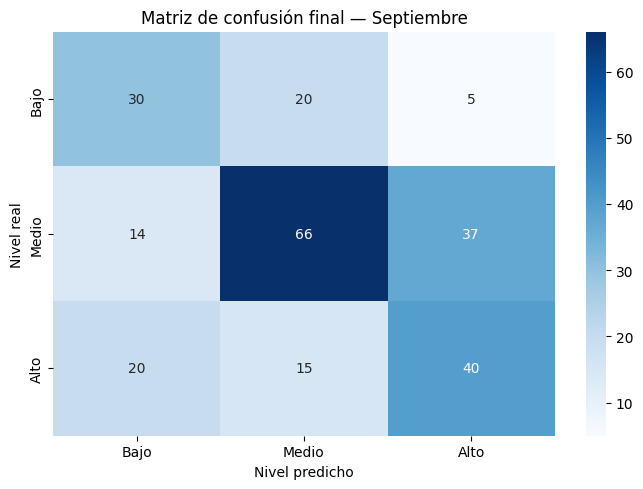

Casos altos correctamente detectados: 40 de 75


In [33]:
orden_clases = ["Bajo", "Medio", "Alto"]

print("REPORTE DE CLASIFICACIÓN FINAL\n")

print(
    classification_report(
        y_test,
        prediccion_final,
        labels=orden_clases,
        zero_division=0
    )
)

matriz_final = confusion_matrix(
    y_test,
    prediccion_final,
    labels=orden_clases
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=orden_clases,
    yticklabels=orden_clases
)

plt.title(
    "Matriz de confusión final — Septiembre"
)
plt.xlabel("Nivel predicho")
plt.ylabel("Nivel real")
plt.tight_layout()
plt.show()

casos_altos_reales = (
    y_test == "Alto"
).sum()

casos_altos_detectados = (
    (y_test == "Alto")
    &
    (prediccion_final == "Alto")
).sum()

print(
    "Casos altos correctamente detectados:",
    casos_altos_detectados,
    "de",
    casos_altos_reales
)

El modelo definitivo corresponde a un algoritmo Random Forest configurado con 300 árboles, profundidad máxima de 6, mínimo de 2 registros por hoja y un peso de 3 para la clase de afluencia alta.

La evaluación final se realizó utilizando septiembre de 2026 como periodo de prueba independiente. El modelo alcanzó una exactitud de 55.06 %, un F1 macro de 53.98 % y un recall de 53.33 % para la clase de afluencia alta. Esto significa que identificó correctamente 40 de los 75 casos reales de afluencia alta.

El modelo mejoró considerablemente la detección de afluencia alta respecto a la versión inicial, que solamente identificaba el 28 % de estos casos. No obstante, debido a la variación observada entre los meses y a la cantidad limitada de información histórica, la predicción deberá utilizarse como una alerta de apoyo para el personal administrativo y no como una decisión automática.

El modelo deberá reentrenarse periódicamente conforme la biblioteca acumule nuevos registros reales. También se recomienda incorporar posteriormente variables relacionadas con el calendario académico, periodos de matrícula, exámenes, vacaciones y feriados.

In [34]:
# Conjunto completo disponible después de la evaluación final
df_entrenamiento_produccion = pd.concat(
    [df_train, df_test],
    ignore_index=True
).sort_values(["Fecha", "Hora"])

X_produccion = df_entrenamiento_produccion[
    variables
].copy()

y_produccion = df_entrenamiento_produccion[
    "NivelAfluencia"
].copy()

modelo_produccion = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    class_weight={
        "Bajo": 1.0,
        "Medio": 1.0,
        "Alto": 3.0
    },
    random_state=42,
    n_jobs=-1
)

modelo_produccion.fit(
    X_produccion,
    y_produccion
)

print("Modelo de producción reentrenado.")
print("Registros utilizados:", len(X_produccion))
print(
    "Periodo:",
    df_entrenamiento_produccion["Fecha"].min(),
    "a",
    df_entrenamiento_produccion["Fecha"].max()
)
print("Variables:", len(variables))
print("Clases:", modelo_produccion.classes_)

Modelo de producción reentrenado.
Registros utilizados: 1183
Periodo: 2026-05-13 00:00:00 a 2026-09-28 00:00:00
Variables: 12
Clases: ['Alto' 'Bajo' 'Medio']


## Exportación del modelo para su integración con Flask

In [35]:
import joblib
import json
import sklearn
from datetime import datetime
from zoneinfo import ZoneInfo

metricas_evaluacion = {
    "accuracy": round(float(accuracy_final), 4),
    "f1_macro": round(float(f1_final), 4),
    "recall_alto": round(float(recall_alto_final), 4),
    "precision_alto": round(
        float(precision_alto_final),
        4
    ),
    "casos_altos_detectados": int(
        casos_altos_detectados
    ),
    "casos_altos_reales": int(
        casos_altos_reales
    )
}

metadatos_modelo = {
    "nombre": "Modelo de predicción de afluencia UNDAC",
    "version": "1.0.0",
    "algoritmo": "RandomForestClassifier",
    "finalidad": (
        "Predecir el nivel de afluencia por fecha y hora"
    ),
    "variables": list(variables),
    "clases": [
        str(clase)
        for clase in modelo_produccion.classes_
    ],
    "limites_afluencia": {
        "bajo_hasta": 7,
        "medio_hasta": 35,
        "alto_desde": 36
    },
    "configuracion": {
        "numero_arboles": 300,
        "profundidad_maxima": 6,
        "minimo_registros_hoja": 2,
        "peso_bajo": 1.0,
        "peso_medio": 1.0,
        "peso_alto": 3.0,
        "random_state": 42
    },
    "metricas_prueba_septiembre": metricas_evaluacion,
    "periodo_entrenamiento": {
        "inicio": str(
            df_entrenamiento_produccion["Fecha"].min().date()
        ),
        "fin": str(
            df_entrenamiento_produccion["Fecha"].max().date()
        )
    },
    "cantidad_registros": int(
        len(df_entrenamiento_produccion)
    ),
    "version_sklearn": sklearn.__version__,
    "fecha_exportacion": datetime.now(
        ZoneInfo("America/Lima")
    ).isoformat(),
    "advertencia": (
        "Modelo de apoyo. La predicción no representa "
        "una garantía exacta de afluencia."
    )
}

paquete_modelo = {
    "modelo": modelo_produccion,
    "metadatos": metadatos_modelo
}

ruta_modelo = "/content/modelo_afluencia_undac.joblib"
ruta_metadatos = (
    "/content/metadatos_modelo_afluencia.json"
)

joblib.dump(
    paquete_modelo,
    ruta_modelo,
    compress=3
)

with open(
    ruta_metadatos,
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        metadatos_modelo,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print("Archivos exportados correctamente:")
print(ruta_modelo)
print(ruta_metadatos)

Archivos exportados correctamente:
/content/modelo_afluencia_undac.joblib
/content/metadatos_modelo_afluencia.json


In [36]:
paquete_verificacion = joblib.load(
    "/content/modelo_afluencia_undac.joblib"
)

modelo_verificado = paquete_verificacion["modelo"]
metadatos_verificados = paquete_verificacion[
    "metadatos"
]

print("Modelo cargado correctamente.")
print(
    "Algoritmo:",
    metadatos_verificados["algoritmo"]
)
print(
    "Versión:",
    metadatos_verificados["version"]
)
print(
    "Cantidad de variables:",
    len(metadatos_verificados["variables"])
)
print(
    "Clases:",
    modelo_verificado.classes_
)

Modelo cargado correctamente.
Algoritmo: RandomForestClassifier
Versión: 1.0.0
Cantidad de variables: 12
Clases: ['Alto' 'Bajo' 'Medio']


In [37]:
from google.colab import files

files.download(
    "/content/modelo_afluencia_undac.joblib"
)

files.download(
    "/content/metadatos_modelo_afluencia.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>